<a href="https://colab.research.google.com/github/suzetteabascal10-byte/Simulacion-I/blob/main/tibasa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **>EJERCICIO DE TIBASA**
para este ejercicio se quiere obtener la probabilidad de que se rebasen los limites de peso en un camion con el limite de 1000 kg







In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random as r

se definen los parametros y el numero de simulaciones que queremos realizar con el numero de tinas que se quiere transportar y los parametros de la distribuciontriangular

In [16]:
capacidad_camion = 1000
n_tinas = 5
n_simulaciones = 100000

a = 190
b = 210
c = 230



definimos la distribucion triangular con la suma de las 5 tinas por dia y se calcula la probabilidad con el histograma para la visualizacion de los datos simulados y se agregan algunos como la media, peso minimo simulado y peso maximo simulado para al final obtener una probabilidad de rebasar los limites de peso en el camion.

[1041.97846107 1027.2365596  1036.21261575 ... 1041.91841526 1043.28730279
 1035.67679939]
Media simulada =  1049.9711005745248
probabilidad que se exceda 0.99761


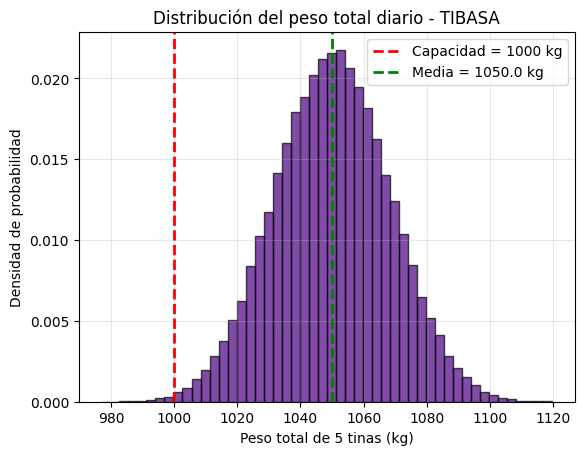

Peso mínimo simulado:  976.9089715966096
Peso máximo simulado: 1119.7442568154124


In [19]:
def triangular(a, b, c, size):
    U = np.random.rand(size)
    F = (b - a) / (c - a)
    x = np.zeros(size)
    cond = U < F
    x[cond] = a + np.sqrt(U[cond] * (c - a) * (b - a))
    x[cond == False] = c - np.sqrt((1 - U[cond == False]) * (c - a) * (c - b))
    return x

S = np.array([np.sum(triangular(a, b, c, n_tinas))
for i in range(n_simulaciones)])
print(S)
w=np.mean(S)
print("Media simulada = ", w)
proba = np.mean(S > capacidad_camion)
print("probabilidad que se exceda", proba)

# Histograma
plt.hist(S, bins=50, density=True, alpha=0.7, color='indigo', edgecolor='black')
plt.axvline(capacidad_camion, color='red', linestyle='dashed', linewidth=2,
            label=f'Capacidad = {capacidad_camion} kg')
plt.axvline(np.mean(S), color='green', linestyle='dashed', linewidth=2,
            label=f'Media = {np.mean(S):.1f} kg')

plt.xlabel('Peso total de 5 tinas (kg)')
plt.ylabel('Densidad de probabilidad')
plt.title('Distribución del peso total diario - TIBASA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



print("Peso mínimo simulado: ",np.min(S) )
print("Peso máximo simulado:" ,np.max(S))
